In [1]:
from enum import Enum

import pandas as pd
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import PandasTools
from rdkit.Chem import AllChem
from rdkit import DataStructs
from rdkit.ML.Cluster import Butina
from pathlib import Path
import numpy as np
import seaborn as sns
import itertools
import tqdm
import numpy as np

sns.set_context("notebook")
from matplotlib import pyplot as plt
from matplotlib.gridspec import GridSpec

In [2]:
class ActivityType(Enum):
    INHIBITION = 1
    IC50 = 2
    KD = 3

# Basic analysis

The data is gerenated from the files in `Data` in the Notebook `Data preparation`.

In [3]:
hips = pd.read_csv("data/hips_avail_data.csv", index_col=0)
hips["date"] = pd.to_datetime(hips["date"])

In [4]:
hips[hips["target"] == "ECF-T"].to_csv("data/ecft_data.csv")

## Compound-target overlap

In [7]:
conc = list()
ecft = list()
rnap = list()
cmpd = list()
for c, g in hips.groupby("compound"):
    covered_targets = np.unique(g.target.values)
    if len(covered_targets) > 1:
        if list(covered_targets) != ["ECF-T", "RNAP"]:
            continue
        g_overlap = (
            g[g["activity_type"] == ActivityType.INHIBITION.name]
            .groupby(["concentration", "target"])
            .mean(numeric_only=True)
        )
        for con in g_overlap.index.get_level_values(0):
            if len(g_overlap.loc[con]) == 2:
                conc.append(con)
                ecft.append(g_overlap.loc[con, "ECF-T"]["activity"])
                rnap.append(g_overlap.loc[con, "RNAP"]["activity"])
                cmpd.append(c)
dd = pd.DataFrame({"concentration": conc, "ECF-T": ecft, "RNAP": rnap, "compound": cmpd})

## HIPS compounds
Read the HIPS compound library.

In [12]:
hips_compounds = PandasTools.LoadSDF(
    "data/HIPS compounds 001-7433.sdf",
    smilesName="SMILES",
    molColName="Molecule",
    includeFingerprints=True,
    removeHs=False,
    strictParsing=True,
)

[13:32:27] Explicit valence for atom # 6 C, 5, is greater than permitted
[13:32:27] ERROR: Could not sanitize molecule ending on line 272297
[13:32:27] ERROR: Explicit valence for atom # 6 C, 5, is greater than permitted
[13:32:27] Explicit valence for atom # 4 N, 4, is greater than permitted
[13:32:27] ERROR: Could not sanitize molecule ending on line 285662
[13:32:27] ERROR: Explicit valence for atom # 4 N, 4, is greater than permitted
[13:32:27] Explicit valence for atom # 26 N, 4, is greater than permitted
[13:32:27] ERROR: Could not sanitize molecule ending on line 295105
[13:32:27] ERROR: Explicit valence for atom # 26 N, 4, is greater than permitted
[13:32:27] Explicit valence for atom # 23 N, 4, is greater than permitted
[13:32:27] ERROR: Could not sanitize molecule ending on line 295219
[13:32:27] ERROR: Explicit valence for atom # 23 N, 4, is greater than permitted
[13:32:28] Explicit valence for atom # 8 N, 4, is greater than permitted
[13:32:28] ERROR: Could not sanitize mo

Helper functions to query the HIPS compound DB.

In [13]:
def entry_from_id(hipscode):
    res = hips_compounds[hips_compounds["HIPS code"] == hipscode]
    if len(res) == 0:
        raise ValueError(f"No compound for '{hipscode}' found.")
    elif len(res) == 1:
        return res.iloc[0]
    else:
        raise ValueError(f"No unique compound for '{hipscode}' found")


mol_from_id = lambda hipscode: entry_from_id(hipscode).Molecule

# Top/bottom performers by IC50

### Best

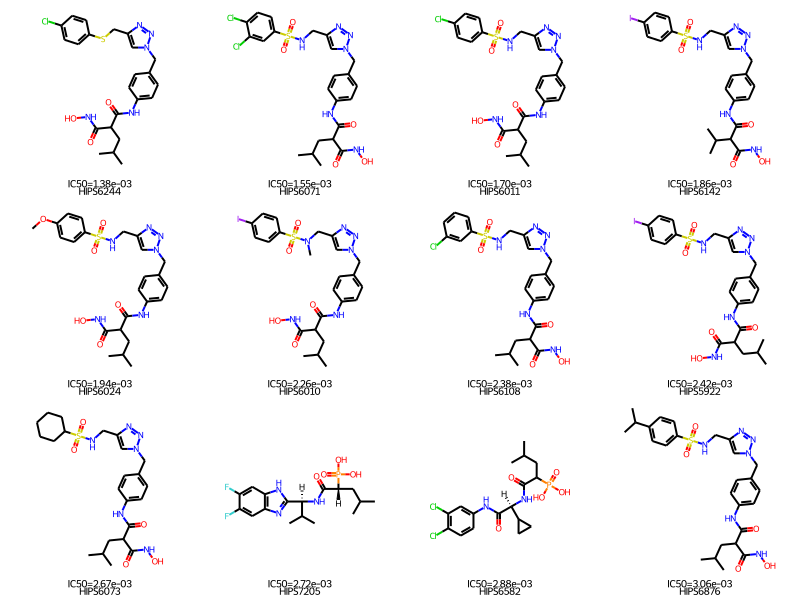

In [14]:
df = hips[hips["target"] == "LasB"]
df = df[df["activity_type"] == ActivityType.IC50.name]
df = df.groupby("compound").agg("mean")
df = df.sort_values(by="activity", ascending=True).iloc[:12]

mols = [mol_from_id(idx) for idx in list(df.index)]

Draw.MolsToGridImage(
    mols,
    molsPerRow=4,
    subImgSize=(200, 200),
    legends=[f"IC50={r.activity:.2e}\n{c}" for c, r in df.iterrows()],
)

### Worst

# Ranking compounds by inhibition and IC50
Hodge ranking by aggregated inhibition values. See Thm. 3 in particular.

__References__:
* [Jiang, Xiaoye, et al. "Statistical ranking and combinatorial Hodge theory." (2008).](https://web.stanford.edu/~yyye/hodgeRank2011.pdf)

In [22]:
def decompose_activity_types(
    df, activity_type, groupby, compound_name_pref="HIPS", min_log_activity=-5
):
    inh = df[
        (df["activity_type"] == activity_type.name)
        & (df["compound"].str.startswith(compound_name_pref))
    ].groupby(groupby)
    inh_lens = inh.agg(len)
    inh = inh.mean(numeric_only=True)
    inh.fillna(min_log_activity, inplace=True)
    inh.loc[inh["log_activity"] == -np.inf, "log_activity"] = min_log_activity
    return inh, inh_lens

In [23]:
def ranking_matrix(df, ic50_bonus=3, clip_min=0, clip_max=100):
    compounds = list(np.unique(df["compound"].values))
    concentrations = np.unique(df["concentration"].dropna().values)
    clip = lambda x: np.clip(x, 0, 100)

    inh, inh_lens = decompose_activity_types(
        df, ActivityType.INHIBITION, ["concentration", "compound"]
    )
    ic50, ic50_lens = decompose_activity_types(df, ActivityType.IC50, ["compound"])

    dim = len(compounds)

    # inhibition - inhibition comparisons
    y_bar_inh = np.zeros((dim, dim))
    w_inh = np.zeros((dim, dim))
    for concentration in tqdm.tqdm(concentrations):
        g = inh.loc[concentration]
        gl = inh_lens.loc[concentration]
        for c_i in g.index:
            i = compounds.index(c_i)
            for c_j in g.index:
                j = compounds.index(c_j)
                # weighting
                w_ij_g = 1 / np.sqrt(
                    1 / inh_lens.loc[concentration, c_j]["activity"]
                    + 1 / inh_lens.loc[concentration, c_i]["activity"]
                )  # (clip(g.loc[c_j, "activity"]) - clip(g.loc[c_i, "activity"])) ** 2
                w_ij_g /= concentration
                assert w_ij_g >= 0, w_ij_g
                # we only account for the sign here to clip the amplitude and account for the noise
                y_bar_inh[i, j] += (
                    w_ij_g * (clip(g.loc[c_j, "activity"]) - clip(g.loc[c_i, "activity"])) / 100
                )
                w_inh[i, j] += w_ij_g

    # ic50 - ic 50 comparisons
    g = gl = c_i = c_j = None
    y_bar_ic50 = np.zeros((dim, dim))
    w_ic50 = np.zeros((dim, dim))
    for c_i in tqdm.tqdm(ic50.index):
        i = compounds.index(c_i)
        for c_j in ic50.index:
            j = compounds.index(c_j)
            w_ij_g = (
                min(ic50_lens.loc[c_j, "log_activity"], ic50_lens.loc[c_i, "log_activity"])
                * ic50_bonus
            )
            y_bar_ic50[i, j] = w_ij_g * (
                ic50.loc[c_i, "log_activity"] - ic50.loc[c_j, "log_activity"]
            )
            w_ic50[i, j] += w_ij_g

    assert np.all(~np.isnan(y_bar_inh))
    assert np.all(~np.isnan(y_bar_ic50))
    y_bar = y_bar_ic50 + y_bar_inh
    w = w_ic50 + w_inh
    y_bar /= w
    w[np.diag_indices_from(w)] = 0

    return y_bar, w

In [24]:
def hodge_rank(y_bar, w):
    laplacian = -w
    laplacian[np.diag_indices_from(w)] = w.sum(0)
    y_bar = np.nan_to_num(y_bar)  # nan to zero
    divergence = (w * y_bar).sum(0)
    scores = -np.linalg.pinv(laplacian) @ divergence

    return scores

In [25]:
def plot_rank_and_rankmat(y_bar, w, scores, ordering):
    y_bar /= w

    fig = plt.figure(figsize=(5, 5.2))

    gs = GridSpec(4, 4)

    ax_joint = fig.add_subplot(gs[1:4, 0:3])
    ax_marg_x = fig.add_subplot(gs[0, 0:3])

    ax_joint.imshow(y_bar[ordering].T[ordering], aspect="auto", cmap="vlag")
    ax_marg_x.plot(scores[ordering])

    plt.setp(ax_marg_x.get_xticklabels(), visible=False)

    ax_joint.set_xlabel("compound")
    ax_marg_x.set_ylabel("Score")

    plt.tight_layout()

    return fig

In [26]:
def plot_rank_ic50_corr(scores, df):
    scores["rank"] = np.arange(len(scores)) + 1

    dd = df.set_index("compound").join(scores.set_index("compound"), rsuffix="_score")
    dd = dd[dd["activity_type"] == "IC50"].groupby("compound").agg("mean")

    dd.sort_values(by="activity", inplace=True)
    dd["ic50_rank"] = np.arange(len(dd))
    dd.sort_values(by="rank", inplace=True)
    dd["rank"] = np.arange(len(dd))

    return sns.scatterplot(data=dd, x="rank", y="ic50_rank"), dd

## ECF-T

In [56]:
df = hips[hips["target"] == "ECF-T"]

Filter out problematic experiments (see remarks in the RNAP sheet).

In [57]:
df = df[~((df["sheet"] == "RNAP") & (df["date"] == pd.Timestamp("2021-04-21")))]

In [58]:
compounds = list(np.unique(df["compound"].values))
concentrations = np.unique(df["concentration"].dropna().values)
y_bar, w = ranking_matrix(df, ic50_bonus=0)

100%|████████████████████████████████████████████████████████████████████████████████████████████| 42/42 [00:00<00:00, 468.81it/s]
/tmp/ipykernel_21361/1675527463.py:54: RuntimeWarning: invalid value encountered in true_divide
  y_bar /= w


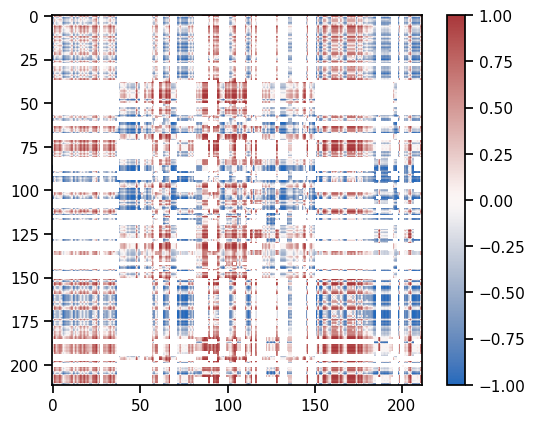

In [59]:
plt.imshow(y_bar, cmap="vlag")
plt.colorbar()

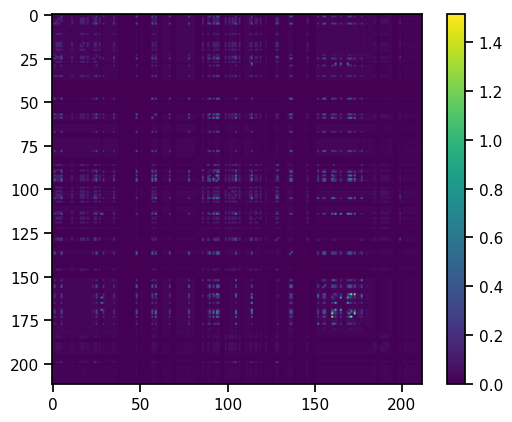

In [60]:
plt.imshow(w)
plt.colorbar()

In [61]:
scores = hodge_rank(y_bar, w)
ordering = scores.argsort()

212 compounds in 27 classes.


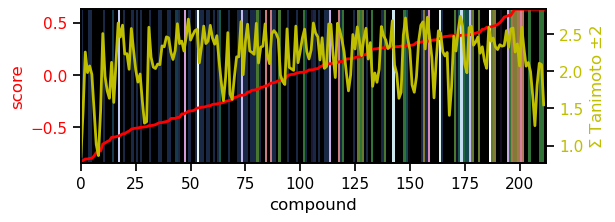

In [62]:
plot_similarity_and_score(compounds, scores)

212 compounds in 27 classes.


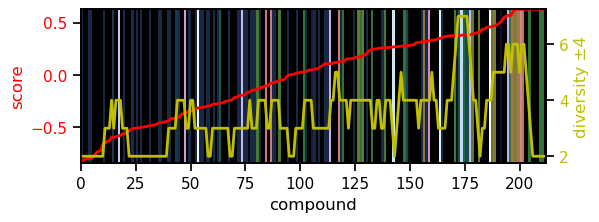

In [63]:
plot_diversity_and_score(compounds, scores)

In [72]:
scores_ecft = pd.DataFrame({"score": scores, "compound": compounds})
scores_ecft.sort_values(by="score", inplace=True)
scores_ecft.to_csv("data/scores_ecft.csv", index=False)

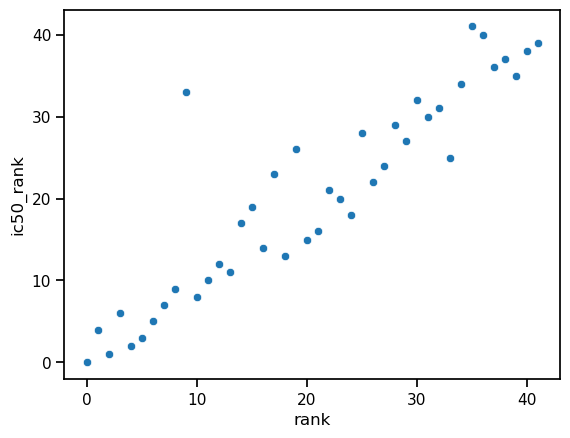

In [73]:
_, dd = plot_rank_ic50_corr(scores_ecft, df)